In [1]:
# Cell 1 — Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, 
                             classification_report,
                             confusion_matrix,
                             roc_auc_score,
                             roc_curve)
import warnings
warnings.filterwarnings('ignore')


✅ Semua library berhasil diimport!

📚 Library yang dipakai:
   pandas, numpy      → Data manipulation
   matplotlib,seaborn → Visualisasi
   sklearn            → Machine Learning


In [2]:
# Cell 2 — Load Data Fresh
import pandas as pd
import numpy as np

df = pd.read_csv(
    r'F:\Data Analyst\Make Portofolio\credit_risk_analysis\german_credit_data.csv',
    index_col=0)

# Verifikasi data asli
print("=== DATA ASLI ===")
print(f"Shape: {df.shape}")
print(f"Risk values: {df['Risk'].unique()}")
print(f"Risk dtype: {df['Risk'].dtype}")
print(df['Risk'].value_counts())

=== DATA ASLI ===
Shape: (1000, 10)
Risk values: ['good' 'bad']
Risk dtype: object
Risk
good    700
bad     300
Name: count, dtype: int64


In [3]:
# Cell 3 — Preprocessing Lengkap
from sklearn.preprocessing import LabelEncoder

# PASTIKAN df masih berisi 'good'/'bad'
print("Risk sebelum mapping:", df['Risk'].unique())

# Step 1: Handle Missing Values
df['Saving accounts'] = df['Saving accounts']\
                           .fillna('unknown')
df['Checking account'] = df['Checking account']\
                            .fillna('unknown')

# Step 2: Feature Engineering
df['monthly_payment'] = df['Credit amount'] / df['Duration']
df['credit_per_age']  = df['Credit amount'] / df['Age']
df['duration_years']  = df['Duration'] / 12
df['high_credit']     = (df['Credit amount'] > 5000)\
                         .astype(int)

# Step 3: Encode Target DULU sebelum fitur lain
df['Risk'] = df['Risk'].map({'good': 0, 'bad': 1})

# Verifikasi mapping berhasil
print("\nRisk setelah mapping:", df['Risk'].unique())
print("Good (0):", (df['Risk']==0).sum())
print("Bad  (1):", (df['Risk']==1).sum())

# Step 4: Encode kolom kategorikal
le = LabelEncoder()
categorical_cols = ['Sex', 'Housing', 
                    'Saving accounts',
                    'Checking account', 'Purpose']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))
    print(f"✅ {col} → encoded")

print(f"\nShape final: {df.shape}")
print(f"Kolom: {df.columns.tolist()}")
print("\n✅ Preprocessing selesai!")

Risk sebelum mapping: ['good' 'bad']

Risk setelah mapping: [0 1]
Good (0): 700
Bad  (1): 300
✅ Sex → encoded
✅ Housing → encoded
✅ Saving accounts → encoded
✅ Checking account → encoded
✅ Purpose → encoded

Shape final: (1000, 14)
Kolom: ['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk', 'monthly_payment', 'credit_per_age', 'duration_years', 'high_credit']

✅ Preprocessing selesai!


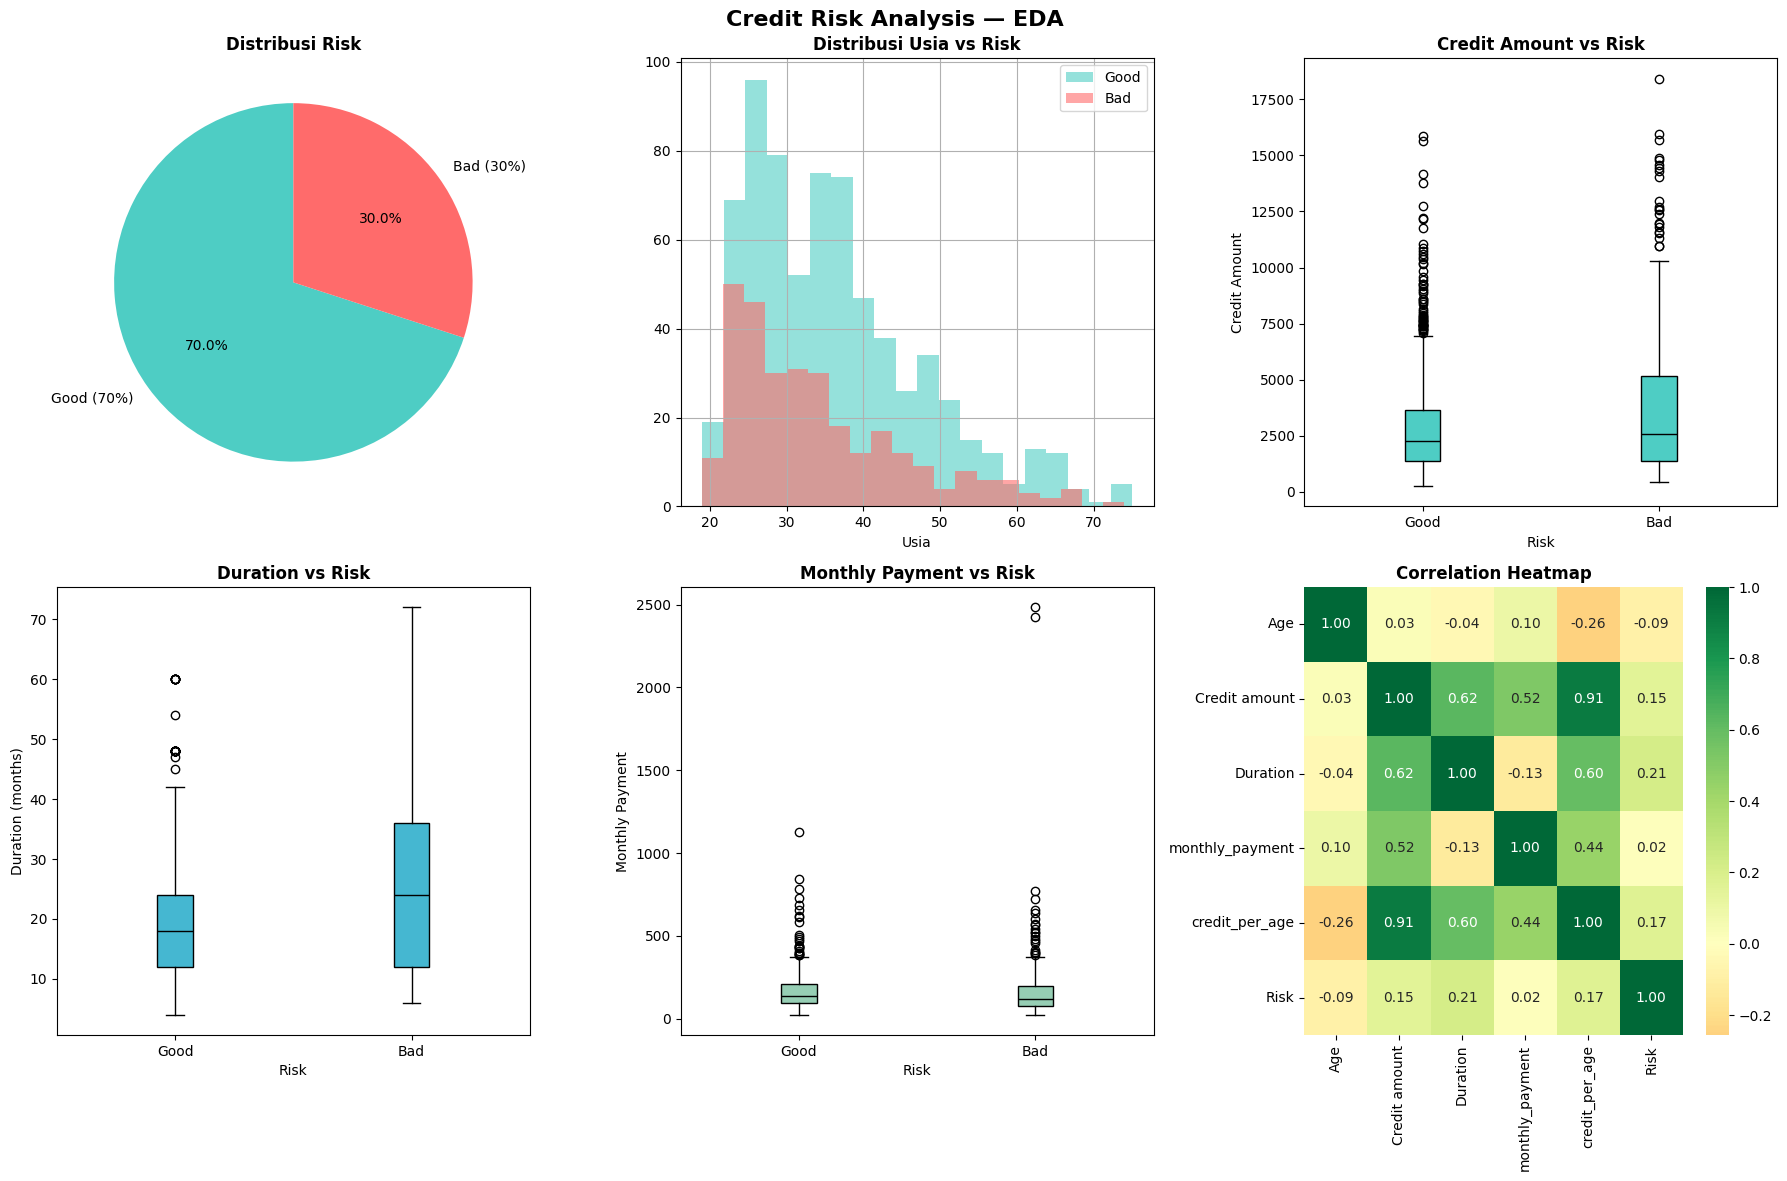

✅ EDA selesai!


In [4]:
# Cell 4 — Exploratory Data Analysis
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Credit Risk Analysis — EDA', 
             fontsize=16, fontweight='bold')

# 1. Distribusi Target
axes[0,0].pie([700, 300], 
              labels=['Good (70%)', 'Bad (30%)'],
              colors=['#4ECDC4', '#FF6B6B'],
              autopct='%1.1f%%',
              startangle=90)
axes[0,0].set_title('Distribusi Risk', 
                     fontweight='bold')

# 2. Distribusi Usia berdasarkan Risk
for risk_val, color in zip([0, 1], 
                           ['#4ECDC4', '#FF6B6B']):
    df[df['Risk'] == risk_val]['Age'].hist(
        ax=axes[0,1], bins=20, alpha=0.6,
        color=color,
        label=f'{"Good" if risk_val==0 else "Bad"}')
axes[0,1].set_title('Distribusi Usia vs Risk',
                     fontweight='bold')
axes[0,1].set_xlabel('Usia')
axes[0,1].legend()

# 3. Credit Amount vs Risk
good = df[df['Risk']==0]['Credit amount']
bad  = df[df['Risk']==1]['Credit amount']
axes[0,2].boxplot([good, bad], 
                   labels=['Good', 'Bad'],
                   patch_artist=True,
                   boxprops=dict(facecolor='#4ECDC4'),
                   medianprops=dict(color='black'))
axes[0,2].set_title('Credit Amount vs Risk',
                     fontweight='bold')
axes[0,2].set_xlabel('Risk')
axes[0,2].set_ylabel('Credit Amount')

# 4. Duration vs Risk
good_dur = df[df['Risk']==0]['Duration']
bad_dur  = df[df['Risk']==1]['Duration']
axes[1,0].boxplot([good_dur, bad_dur],
                   labels=['Good', 'Bad'],
                   patch_artist=True,
                   boxprops=dict(facecolor='#45B7D1'),
                   medianprops=dict(color='black'))
axes[1,0].set_title('Duration vs Risk',
                     fontweight='bold')
axes[1,0].set_xlabel('Risk')
axes[1,0].set_ylabel('Duration (months)')

# 5. Monthly Payment vs Risk
good_mp = df[df['Risk']==0]['monthly_payment']
bad_mp  = df[df['Risk']==1]['monthly_payment']
axes[1,1].boxplot([good_mp, bad_mp],
                   labels=['Good', 'Bad'],
                   patch_artist=True,
                   boxprops=dict(facecolor='#96CEB4'),
                   medianprops=dict(color='black'))
axes[1,1].set_title('Monthly Payment vs Risk',
                     fontweight='bold')
axes[1,1].set_xlabel('Risk')
axes[1,1].set_ylabel('Monthly Payment')

# 6. Correlation Heatmap
numeric_cols = ['Age', 'Credit amount', 
                'Duration', 'monthly_payment',
                'credit_per_age', 'Risk']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f',
            cmap='RdYlGn', ax=axes[1,2],
            center=0)
axes[1,2].set_title('Correlation Heatmap',
                     fontweight='bold')

plt.tight_layout()
plt.savefig('eda_credit_risk.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA selesai!")

In [5]:
# Cell 5 — Persiapan Modeling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("=" * 50)
print("PERSIAPAN MODELING")
print("=" * 50)

# Step 1: Drop credit_per_age SEBELUM split
# Alasan: multikolinearitas tinggi (0.91) 
# dengan Credit amount
print("\n🗑️ Drop credit_per_age...")
df_model = df.drop('credit_per_age', axis=1)
print(f"Shape setelah drop: {df_model.shape}")

# Step 2: Pisahkan X dan y
X = df_model.drop('Risk', axis=1)
y = df_model['Risk']

print(f"\n📊 Shape X (features): {X.shape}")
print(f"📊 Shape y (target)  : {y.shape}")
print(f"\n📋 Fitur yang dipakai ({len(X.columns)} fitur):")
for i, col in enumerate(X.columns, 1):
    print(f"   {i:2}. {col}")

# Step 3: Train Test Split (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\n📊 Hasil Train-Test Split:")
print(f"   X_train: {X_train.shape}")
print(f"   X_test : {X_test.shape}")
print(f"\n📊 Distribusi y_train:")
print(y_train.value_counts())
print(f"   Proporsi: {y_train.value_counts(normalize=True).round(2).to_dict()}")
print(f"\n📊 Distribusi y_test:")
print(y_test.value_counts())
print(f"   Proporsi: {y_test.value_counts(normalize=True).round(2).to_dict()}")

# Step 4: StandardScaler untuk Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"\n✅ StandardScaler selesai!")
print(f"\n✅ Semua persiapan modeling selesai!")

PERSIAPAN MODELING

🗑️ Drop credit_per_age...
Shape setelah drop: (1000, 13)

📊 Shape X (features): (1000, 12)
📊 Shape y (target)  : (1000,)

📋 Fitur yang dipakai (12 fitur):
    1. Age
    2. Sex
    3. Job
    4. Housing
    5. Saving accounts
    6. Checking account
    7. Credit amount
    8. Duration
    9. Purpose
   10. monthly_payment
   11. duration_years
   12. high_credit

📊 Hasil Train-Test Split:
   X_train: (800, 12)
   X_test : (200, 12)

📊 Distribusi y_train:
Risk
0    560
1    240
Name: count, dtype: int64
   Proporsi: {0: 0.7, 1: 0.3}

📊 Distribusi y_test:
Risk
0    140
1     60
Name: count, dtype: int64
   Proporsi: {0: 0.7, 1: 0.3}

✅ StandardScaler selesai!

✅ Semua persiapan modeling selesai!


In [7]:
# Cell 6 — Modeling
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score,
                             classification_report,
                             confusion_matrix,
                             roc_auc_score,
                             roc_curve)

print("=" * 50)
print("MODELING — LOGISTIC REGRESSION")
print("=" * 50)

# ==========================================
# MODEL 1: LOGISTIC REGRESSION
# ==========================================
lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:,1]

print("\n📊 HASIL LOGISTIC REGRESSION:")
print(f"Accuracy : {accuracy_score(y_test, y_pred_lr):.3f}")
print(f"AUC-ROC  : {roc_auc_score(y_test, y_prob_lr):.3f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_lr,
      target_names=['Good', 'Bad']))

print("\n📊 Confusion Matrix LR:")
cm_lr = confusion_matrix(y_test, y_pred_lr)
print(f"         Pred Good  Pred Bad")
print(f"Act Good    {cm_lr[0,0]:3d}       {cm_lr[0,1]:3d}")
print(f"Act Bad     {cm_lr[1,0]:3d}       {cm_lr[1,1]:3d}")

print("\n" + "=" * 50)
print("MODELING — RANDOM FOREST")
print("=" * 50)

# ==========================================
# MODEL 2: RANDOM FOREST
# ==========================================
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

print("\n📊 HASIL RANDOM FOREST:")
print(f"Accuracy : {accuracy_score(y_test, y_pred_rf):.3f}")
print(f"AUC-ROC  : {roc_auc_score(y_test, y_prob_rf):.3f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_rf,
      target_names=['Good', 'Bad']))

print("\n📊 Confusion Matrix RF:")
cm_rf = confusion_matrix(y_test, y_pred_rf)
print(f"         Pred Good  Pred Bad")
print(f"Act Good    {cm_rf[0,0]:3d}       {cm_rf[0,1]:3d}")
print(f"Act Bad     {cm_rf[1,0]:3d}       {cm_rf[1,1]:3d}")

MODELING — LOGISTIC REGRESSION

📊 HASIL LOGISTIC REGRESSION:
Accuracy : 0.730
AUC-ROC  : 0.764

Classification Report:
              precision    recall  f1-score   support

        Good       0.78      0.86      0.82       140
         Bad       0.57      0.42      0.48        60

    accuracy                           0.73       200
   macro avg       0.67      0.64      0.65       200
weighted avg       0.71      0.73      0.72       200


📊 Confusion Matrix LR:
         Pred Good  Pred Bad
Act Good    121        19
Act Bad      35        25

MODELING — RANDOM FOREST

📊 HASIL RANDOM FOREST:
Accuracy : 0.755
AUC-ROC  : 0.756

Classification Report:
              precision    recall  f1-score   support

        Good       0.80      0.86      0.83       140
         Bad       0.61      0.50      0.55        60

    accuracy                           0.76       200
   macro avg       0.71      0.68      0.69       200
weighted avg       0.74      0.76      0.75       200


📊 Confusion M

THRESHOLD TUNING — RANDOM FOREST

 Threshold   Accuracy  Precision     Recall         F1
-------------------------------------------------------
       0.3      0.665      0.461      0.683      0.550
       0.4      0.710      0.515      0.567      0.540
       0.5      0.750      0.596      0.517      0.554 ← DEFAULT
       0.6      0.755      0.677      0.350      0.462
       0.7      0.735      0.818      0.150      0.254


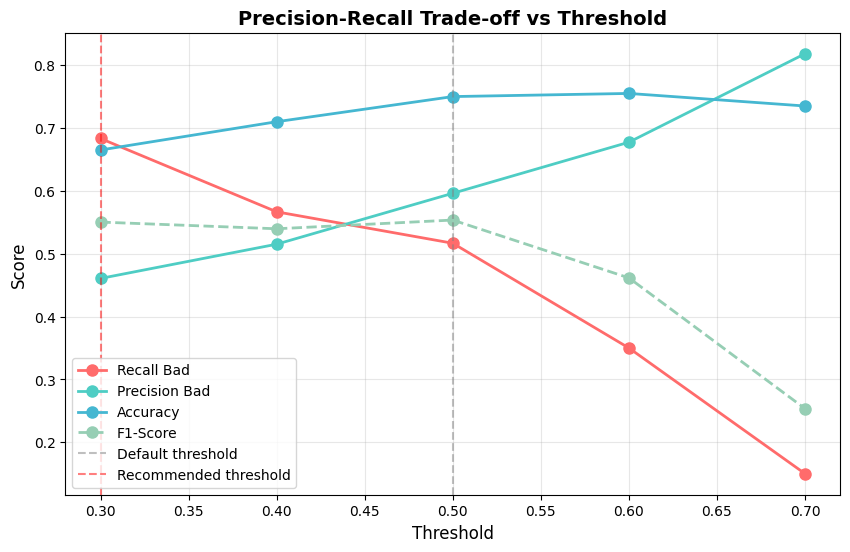


✅ Threshold tuning selesai!


In [8]:
# Cell 8 — Threshold Tuning
print("=" * 50)
print("THRESHOLD TUNING — RANDOM FOREST")
print("=" * 50)

# Probabilitas prediksi RF
# y_prob_rf sudah ada dari Cell 6

# Test berbagai threshold
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

print(f"\n{'Threshold':>10} {'Accuracy':>10} "
      f"{'Precision':>10} {'Recall':>10} "
      f"{'F1':>10}")
print("-" * 55)

results = []
for thresh in thresholds:
    y_pred_thresh = (y_prob_rf >= thresh).astype(int)
    
    from sklearn.metrics import (precision_score, 
                                  recall_score,
                                  f1_score)
    
    acc  = accuracy_score(y_test, y_pred_thresh)
    prec = precision_score(y_test, y_pred_thresh,
                           zero_division=0)
    rec  = recall_score(y_test, y_pred_thresh)
    f1   = f1_score(y_test, y_pred_thresh,
                    zero_division=0)
    
    results.append({
        'threshold': thresh,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1
    })
    
    marker = " ← DEFAULT" if thresh == 0.5 else ""
    print(f"{thresh:>10.1f} {acc:>10.3f} "
          f"{prec:>10.3f} {rec:>10.3f} "
          f"{f1:>10.3f}{marker}")

# Visualisasi trade-off
results_df = pd.DataFrame(results)

plt.figure(figsize=(10, 6))
plt.plot(results_df['threshold'], 
         results_df['recall'],
         'o-', color='#FF6B6B', 
         linewidth=2, markersize=8,
         label='Recall Bad')
plt.plot(results_df['threshold'],
         results_df['precision'],
         'o-', color='#4ECDC4',
         linewidth=2, markersize=8,
         label='Precision Bad')
plt.plot(results_df['threshold'],
         results_df['accuracy'],
         'o-', color='#45B7D1',
         linewidth=2, markersize=8,
         label='Accuracy')
plt.plot(results_df['threshold'],
         results_df['f1'],
         'o--', color='#96CEB4',
         linewidth=2, markersize=8,
         label='F1-Score')

plt.axvline(x=0.5, color='gray',
            linestyle='--', alpha=0.5,
            label='Default threshold')
plt.axvline(x=0.3, color='red',
            linestyle='--', alpha=0.5,
            label='Recommended threshold')

plt.xlabel('Threshold', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Precision-Recall Trade-off vs Threshold',
          fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.savefig('threshold_tuning.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Threshold tuning selesai!")

FEATURE IMPORTANCE — RANDOM FOREST

📊 Feature Importance:
         Feature  Importance
 monthly_payment    0.170713
   Credit amount    0.170237
             Age    0.135034
Checking account    0.123538
        Duration    0.080328
  duration_years    0.072495
         Purpose    0.069490
 Saving accounts    0.061459
             Job    0.046282
         Housing    0.035526
             Sex    0.023693
     high_credit    0.011204


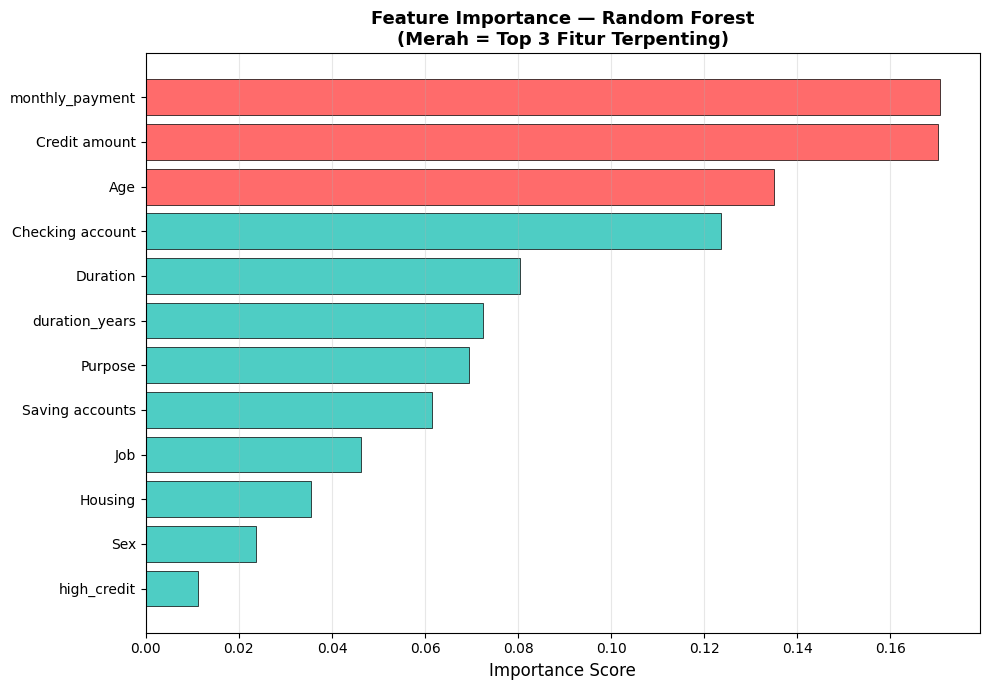

✅ Feature importance selesai!


In [9]:
# Cell 9 — Feature Importance
print("=" * 50)
print("FEATURE IMPORTANCE — RANDOM FOREST")
print("=" * 50)

# Ambil feature importance dari RF
feature_names = X_train.columns.tolist()
importances = rf_model.feature_importances_

# Buat dataframe
feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("\n📊 Feature Importance:")
print(feat_imp.to_string(index=False))

# Visualisasi
plt.figure(figsize=(10, 7))
colors = ['#FF6B6B' if i < 3 else '#4ECDC4' 
          for i in range(len(feat_imp))]

plt.barh(feat_imp['Feature'], 
         feat_imp['Importance'],
         color=colors,
         edgecolor='black',
         linewidth=0.5)

plt.xlabel('Importance Score', fontsize=12)
plt.title('Feature Importance — Random Forest\n'
          '(Merah = Top 3 Fitur Terpenting)',
          fontsize=13, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('feature_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Feature importance selesai!")

In [10]:
# Cell 10 — Business Insight & Rekomendasi
print("=" * 60)
print("CREDIT RISK ANALYSIS — BUSINESS INSIGHTS")
print("=" * 60)

print("""
📊 RINGKASAN MODEL
─────────────────────────────────────────────────────
Model Terpilih  : Random Forest (threshold = 0.3)
Recall Bad      : 68.3% (dari 50% default)
AUC-ROC         : 0.756

Artinya:
→ Dari 100 nasabah yang BENAR-BENAR berisiko
→ 68 berhasil terdeteksi oleh model ✅
→ 32 masih lolos (perlu monitoring) ⚠️
─────────────────────────────────────────────────────

🎯 TOP 3 FAKTOR RISIKO GAGAL BAYAR
─────────────────────────────────────────────────────
1. Monthly Payment (Cicilan Bulanan) — TERPENTING
   → Nasabah dengan cicilan besar relatif 
     terhadap kemampuannya = BERISIKO TINGGI
   → Red flag: cicilan > 30% estimasi income

2. Credit Amount (Jumlah Pinjaman)
   → Pinjaman besar = beban lebih berat
   → Perketat verifikasi untuk pinjaman besar

3. Age (Usia Nasabah)
   → Nasabah muda (< 25 tahun) lebih berisiko
   → Pertimbangkan syarat tambahan untuk 
     nasabah di bawah 25 tahun
─────────────────────────────────────────────────────

💼 REKOMENDASI STRATEGI BISNIS
─────────────────────────────────────────────────────
1. SCREENING CICILAN (Prioritas Utama!)
   → Buat aturan: cicilan maksimal 30-40% income
   → Hitung monthly_payment saat aplikasi masuk
   → Otomatis reject jika melebihi batas

2. TIER PINJAMAN BERDASARKAN RISIKO
   → Pinjaman < 2,000 DM  → proses normal
   → Pinjaman 2,000-5,000 → verifikasi lebih
   → Pinjaman > 5,000 DM  → verifikasi ketat

3. PROGRAM KHUSUS NASABAH MUDA
   → Usia < 25 tahun → limit pinjaman lebih kecil
   → Wajib ada co-borrower atau jaminan
   → Beri edukasi finansial

4. MONITORING BERBASIS MODEL
   → Gunakan model untuk scoring semua aplikasi
   → Probabilitas > 0.3 → review manual
   → Probabilitas > 0.7 → otomatis reject

5. REVIEW BERKALA
   → Evaluasi model setiap 6 bulan
   → Update threshold sesuai kondisi ekonomi
   → Retrain model jika data baru tersedia
─────────────────────────────────────────────────────
""")
print("✅ Business Insight selesai!")


CREDIT RISK ANALYSIS — BUSINESS INSIGHTS

📊 RINGKASAN MODEL
─────────────────────────────────────────────────────
Model Terpilih  : Random Forest (threshold = 0.3)
Recall Bad      : 68.3% (dari 50% default)
AUC-ROC         : 0.756

Artinya:
→ Dari 100 nasabah yang BENAR-BENAR berisiko
→ 68 berhasil terdeteksi oleh model ✅
→ 32 masih lolos (perlu monitoring) ⚠️
─────────────────────────────────────────────────────

🎯 TOP 3 FAKTOR RISIKO GAGAL BAYAR
─────────────────────────────────────────────────────
1. Monthly Payment (Cicilan Bulanan) — TERPENTING
   → Nasabah dengan cicilan besar relatif 
     terhadap kemampuannya = BERISIKO TINGGI
   → Red flag: cicilan > 30% estimasi income

2. Credit Amount (Jumlah Pinjaman)
   → Pinjaman besar = beban lebih berat
   → Perketat verifikasi untuk pinjaman besar

3. Age (Usia Nasabah)
   → Nasabah muda (< 25 tahun) lebih berisiko
   → Pertimbangkan syarat tambahan untuk 
     nasabah di bawah 25 tahun
───────────────────────────────────────────────